In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU

In [2]:
df = pd.read_csv(r"C:\Users\ASUS\OneDrive\Desktop\TY-Dl-codes\Airline Passenger Satisfaction(7)\train.csv")

# Clean column names (prevents hidden space errors)
df.columns = df.columns.str.strip()

# Use only first 10,000 rows for faster training
df = df.head(10000)

print("Shape:", df.shape)
df.head()

Shape: (10000, 25)


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [3]:
# Drop unwanted columns (safe drop)
for col in ["Unnamed: 0", "id"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Fill missing Arrival Delay
if "Arrival Delay in Minutes" in df.columns:
    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(0)

print("Missing values handled.")

Missing values handled.


In [4]:
# Drop unwanted columns (safe drop)
for col in ["Unnamed: 0", "id"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# Fill missing Arrival Delay
if "Arrival Delay in Minutes" in df.columns:
    df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(0)

print("Missing values handled.")

Missing values handled.


In [5]:
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

In [6]:
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col])

In [7]:
df["satisfaction"] = df["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

In [8]:
X = df.drop("satisfaction", axis=1)
y = df["satisfaction"].values

# Normalize all numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Shape:", X_train.shape)

Train Shape: (8000, 22)


In [9]:
# Activation functions
def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)
def leaky_relu(x): return np.where(x > 0, x, 0.01 * x)

# Derivatives
def sigmoid_deriv(x): return sigmoid(x) * (1 - sigmoid(x))
def tanh_deriv(x): return 1 - np.tanh(x)**2
def relu_deriv(x): return np.where(x > 0, 1, 0)
def leaky_relu_deriv(x): return np.where(x > 0, 1, 0.01)

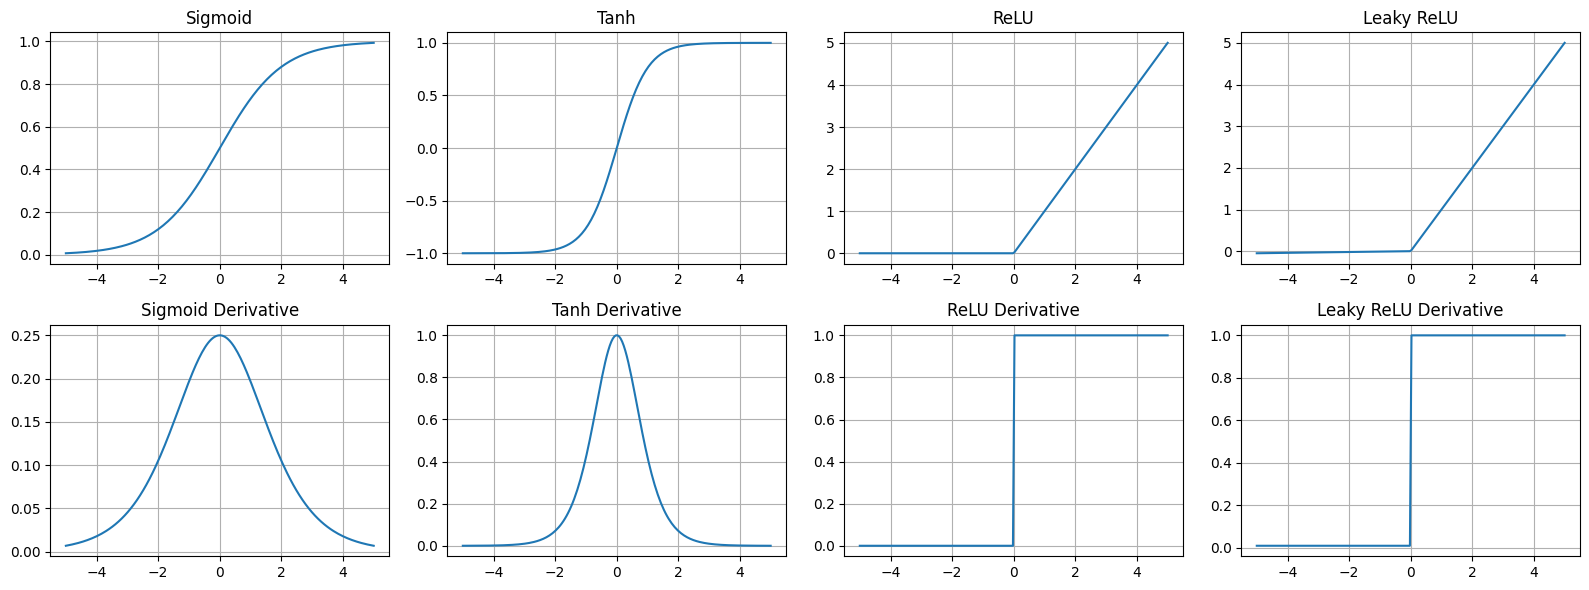

In [10]:
x = np.linspace(-5, 5, 200)

functions = [sigmoid, tanh, relu, leaky_relu]
derivatives = [sigmoid_deriv, tanh_deriv, relu_deriv, leaky_relu_deriv]
titles = ["Sigmoid", "Tanh", "ReLU", "Leaky ReLU"]

plt.figure(figsize=(16,6))

# First row: Functions
for i in range(4):
    plt.subplot(2, 4, i+1)
    plt.plot(x, functions[i](x))
    plt.title(titles[i])
    plt.grid()

# Second row: Derivatives
for i in range(4):
    plt.subplot(2, 4, i+5)
    plt.plot(x, derivatives[i](x))
    plt.title(titles[i] + " Derivative")
    plt.grid()

plt.tight_layout()
plt.show()

In [11]:
def build_model(activation_name):
    model = Sequential()
    
    if activation_name == "leaky_relu":
        model.add(Dense(128, input_shape=(X_train.shape[1],)))
        model.add(LeakyReLU(alpha=0.01))
        model.add(Dense(64))
        model.add(LeakyReLU(alpha=0.01))
    else:
        model.add(Dense(128, activation=activation_name, input_shape=(X_train.shape[1],)))
        model.add(Dense(64, activation=activation_name))
    
    model.add(Dense(1, activation="sigmoid"))
    return model

In [12]:
activations = ["sigmoid", "tanh", "relu", "leaky_relu"]
histories = {}
test_results = {}
train_times = {}

for act in activations:
    print(f"\nTraining model with {act.upper()} activation...")
    
    model = build_model(act)
    
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    start = time.time()
    
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.2,
        verbose=0
    )
    
    end = time.time()
    
    # Store results
    histories[act] = history
    train_times[act] = end - start
    
    # Test evaluation
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    test_results[act] = (loss, acc)


Training model with SIGMOID activation...


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training model with TANH activation...

Training model with RELU activation...

Training model with LEAKY_RELU activation...


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


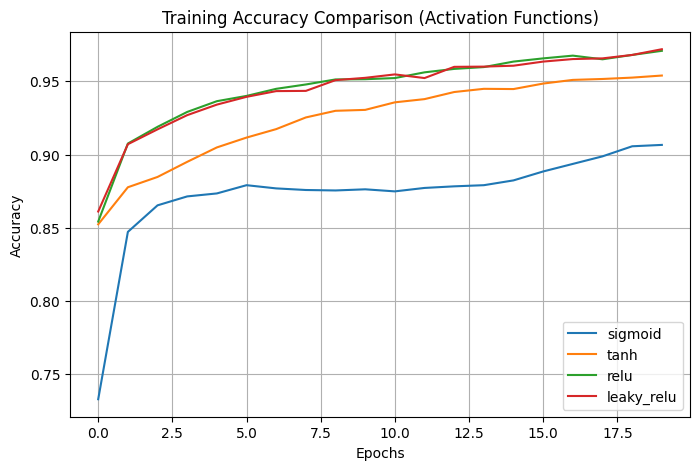

In [13]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(histories[act].history["accuracy"], label=act)

plt.title("Training Accuracy Comparison (Activation Functions)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

In [14]:
summary = []

for act in activations:
    train_acc = histories[act].history["accuracy"][-1]
    val_acc = histories[act].history["val_accuracy"][-1]
    test_acc = test_results[act][1]
    
    # Epoch to reach 80% accuracy
    epochs_80 = next(
        (i+1 for i, acc in enumerate(histories[act].history["accuracy"]) if acc > 0.80),
        "Not reached"
    )
    
    summary.append([act, train_acc, val_acc, test_acc, epochs_80])

summary_df = pd.DataFrame(
    summary,
    columns=["Activation", "Train Acc", "Val Acc", "Test Acc", "Epochs to >80% Acc"]
)

summary_df

,Activation,Train Acc,Val Acc,Test Acc,Epochs to >80% Acc
0,sigmoid,0.906563,0.905625,0.9110,2
1,tanh,0.953906,0.936875,0.9280,1
2,relu,0.970781,0.936875,0.9360,1
3,leaky_relu,0.971875,0.925000,0.9235,1
